In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yfin
yfin.pdr_override()

In [ ]:
start = '2015-09-01'
end = '2023-03-02'

df = pdr.get_data_yahoo('LTC-USD', start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-09-01,2.84742,2.87549,2.80563,2.82001,2.82001,1376040
2015-09-02,2.81981,2.82813,2.75730,2.79545,2.79545,2423010
2015-09-03,2.79669,2.80446,2.57997,2.63314,2.63314,2210590
2015-09-04,2.63814,2.72467,2.63334,2.70112,2.70112,1441530
2015-09-05,2.70205,2.94305,2.66153,2.91954,2.91954,2666820


In [ ]:
df = df.reset_index()
df = df.drop(['Date','Adj Close'], axis = 1)

In [ ]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_training_arr = scaler.fit_transform(data_training)
data_training_arr
data_training_arr.shape

(1917, 1)

In [ ]:
x_train = []
y_train = []

In [ ]:
for i in range(100, data_training_arr.shape[0]):
  x_train.append(data_training_arr[i-100: i])
  y_train.append(data_training_arr[i, 0])

In [ ]:
x_train = np.array(x_train)
y_train = np.array(y_train)
print(x_train.shape)
print(y_train.shape)

(1817, 100, 1)
(1817,)


In [ ]:
from sklearn.svm import SVR
model = SVR(kernel='rbf',gamma=0.5, C=10, epsilon = 0.05)

In [ ]:
nsamples, nx, ny = x_train.shape
d2_train_dataset = x_train.reshape((nsamples,nx*ny))
model.fit(d2_train_dataset, y_train)

SVR(C=10, epsilon=0.05, gamma=0.5)

In [ ]:
past_100 = data_training.tail(100)
final_df = past_100.append(data_testing, ignore_index = True)
input_data = scaler.fit_transform(final_df)
x_test =[]
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100: i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

<ipython-input-14-321680debaf9>:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_df = past_100.append(data_testing, ignore_index = True)


In [ ]:
y_train_pred = model.predict(d2_train_dataset).reshape(-1,1)
nsamples1, nx1, ny1 = x_test.shape
d21_train_dataset = x_test.reshape((nsamples1,nx1*ny1))
y_test_pred = model.predict(d21_train_dataset).reshape(-1,1)

In [ ]:
scaler = scaler.scale_
scale_factor = 1/scaler[0]
y_test = y_test * scale_factor
y_test_pred = y_test_pred * scale_factor

In [ ]:
# y_train_pred = scaler.inverse_transform(y_train_pred)
# y_test_pred = scaler.inverse_transform(y_test_pred)
# y_test = scaler.inverse_transform(y_test)

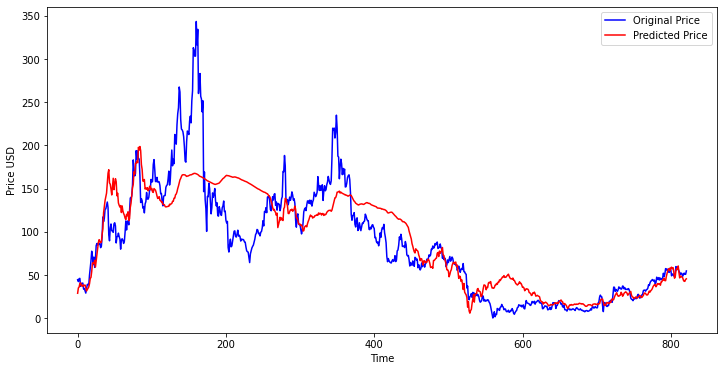

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_test_pred , 'r' , label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price USD')
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(y_test, y_test_pred))
print('Test RMSE: %f' % rmse)

Test RMSE: 34.389483


In [ ]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [ ]:
LR_MAPE= MAPE(y_test,y_test_pred)
print("MAPE: ",LR_MAPE)

MAPE:  256.8003910620292
